# CMT307 Applied Machine Learning — ASHRAE Great Energy Predictor III

**Cardiff University | Spring 2025/26 | Energy Usage Prediction**

---

| | |
|---|---|
| **Full name** | Zahra Sabouri |
| **Student ID** | 25095415 |
| **Email** | SabouriZ@cardiff.ac.uk |
| **Role** | Data Merging & Integration Hub |

## Notebook Summary

1. Raw Data Loading and Cross-Table Merging (train + metadata + weather)
2. Central Preprocessing Pipeline producing the final train/validation datasets
3. Five-Model Ensemble Comparison (Hard Voting and Soft Voting)
4. Best Ensemble Predictions Saved

**Notes on this notebook.** The notebook covers cross-table merging, the central preprocessing pipeline producing the final 49-feature dataset, and the five-model ensemble comparison. Wahid contributed a variable-name cleanup pass (commit `4058d38`).

## 1. Raw Data Loading and Cross-Table Merging

In [28]:
import pandas as pd
import os

DATA_DIR = '../data/ashrae-energy-prediction'

train    = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'), parse_dates=['timestamp'])
metadata = pd.read_csv(os.path.join(DATA_DIR, 'building_metadata.csv'))
weather  = pd.read_csv(os.path.join(DATA_DIR, 'weather_train.csv'), parse_dates=['timestamp'])

print('train:   ', train.shape)
print('metadata:', metadata.shape)
print('weather: ', weather.shape)

train:    (20216100, 4)
metadata: (1449, 6)
weather:  (139773, 9)


In [29]:
# Check all building_ids in train exist in metadata
missing_ids = set(train['building_id']) - set(metadata['building_id'])
print(f'building_ids in train not in metadata: {len(missing_ids)}')
print(f'unique buildings in train:    {train["building_id"].nunique()}')
print(f'unique buildings in metadata: {metadata["building_id"].nunique()}')

building_ids in train not in metadata: 0
unique buildings in train:    1449
unique buildings in metadata: 1449


In [30]:
# Merge train + metadata on building_id
merged_train = train.merge(metadata, on='building_id', how='left')
print('After train + metadata:', merged_train.shape)  # rows must stay at 20,216,100

# Merge + weather on site_id + timestamp
merged_train = merged_train.merge(weather, on=['site_id', 'timestamp'], how='left')
print('After + weather:       ', merged_train.shape)  # must still be 20,216,100

After train + metadata: (20216100, 9)
After + weather:        (20216100, 16)


In [31]:
# Null counts after merge
nulls = merged_train.isnull().sum()
print(nulls[nulls > 0])

year_built            12127645
floor_count           16709167
air_temperature          96658
cloud_coverage         8825365
dew_temperature         100140
precip_depth_1_hr      3749023
sea_level_pressure     1231669
wind_direction         1449048
wind_speed              143676
dtype: int64


In [32]:
# Save merged train file as CSV
os.makedirs('../data_processed', exist_ok=True)
merged_train.to_csv('../data_processed/merged_train.csv', index=False)
print('Saved merged_train.csv to data_processed/')

Saved merged_train.csv to data_processed/


### Key Findings

- Loaded the three files used by the final workflow: train (20,216,100 rows), metadata (1,449), and weather_train (139,773)
- All 1,449 building IDs in train are present in metadata ? no orphan records
- The train merge preserved row count exactly (20,216,100) ? no row duplication or loss
- 16 columns in the merged training table (4 original + 5 metadata + 7 weather features)
- Columns with missing values after merge:
  - `year_built`: 60% missing ? sparse in source metadata
  - `floor_count`: 83% missing ? sparse in source metadata
  - `cloud_coverage`: 44% missing ? weather station gaps
  - `precip_depth_1_hr`: 19% missing
  - `sea_level_pressure`: 6% missing
  - `wind_direction`: 7% missing
  - `air_temperature`, `dew_temperature`, `wind_speed`: <1% missing
- Missing weather values are due to gaps in the original weather station recordings, not a merge error
- Saved: `merged_train.csv` to `data_processed/`
- No unlabeled competition-test merge is included; the final project evaluates on the November-December 2016 validation split.

## 2. Central Preprocessing Pipeline

In [33]:
import pandas as pd
import numpy as np
import os
import gc

PROCESSED_DIR = '../data_processed'
DATA_DIR      = '../data/ashrae-energy-prediction'
OUTPUTS_DIR   = '../outputs'

# Load the merged train file as the central preprocessing pipeline base.
print("Loading merged train file...")
df_train = pd.read_csv(
    os.path.join(PROCESSED_DIR, 'merged_train.csv'),
    dtype={'building_id': 'int16', 'meter': 'int8', 'site_id': 'int8'},
    parse_dates=['timestamp']
)

print(f"df_train : {df_train.shape}")
print(f"Columns  : {list(df_train.columns)}")

Loading merged train file...
df_train : (20216100, 16)
Columns  : ['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id', 'primary_use', 'square_feet', 'year_built', 'floor_count', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed']


In [34]:
# Building Metadata Preprocessing and Encoding

# A: Flag missing floor_count BEFORE imputing (used as a model feature itself)
df_train['missing_floor_count_flag'] = df_train['floor_count'].isnull().astype(np.int8)

# B: Impute floor_count ? group median cascade (primary_use + site_id + sqft_bin ? fallbacks)
df_train['sqft_bin'] = pd.qcut(df_train['square_feet'], q=5, duplicates='drop')
df_train['floor_count'] = df_train['floor_count'].fillna(
    df_train.groupby(['primary_use', 'site_id', 'sqft_bin'], observed=True)['floor_count'].transform('median'))
df_train['floor_count'] = df_train['floor_count'].fillna(
    df_train.groupby(['primary_use', 'sqft_bin'], observed=True)['floor_count'].transform('median'))
df_train['floor_count'] = df_train['floor_count'].fillna(
    df_train.groupby('sqft_bin', observed=True)['floor_count'].transform('median'))
df_train['floor_count'] = df_train['floor_count'].fillna(df_train['floor_count'].median())
df_train['floor_count'] = df_train['floor_count'].round().astype(np.int8)
df_train.drop(columns=['sqft_bin'], inplace=True)

# C: Impute year_built ? group median cascade
df_train['year_built'] = df_train['year_built'].fillna(
    df_train.groupby(['primary_use', 'site_id'], observed=True)['year_built'].transform('median'))
df_train['year_built'] = df_train['year_built'].fillna(
    df_train.groupby('primary_use', observed=True)['year_built'].transform('median'))
df_train['year_built'] = df_train['year_built'].fillna(df_train['year_built'].median())

# D: Derived features
df_train['building_age']    = (2016 - df_train['year_built']).astype(np.int16)
df_train['log_square_feet'] = np.log1p(df_train['square_feet']).astype(np.float32)

# E: One-hot encode primary_use
all_uses = sorted(df_train['primary_use'].unique())
for use in all_uses:
    col = f'use_{use}'
    df_train[col] = (df_train['primary_use'] == use).astype(np.int8)

# F: Drop raw columns replaced by engineered ones
df_train.drop(columns=[c for c in ['primary_use', 'square_feet', 'year_built'] if c in df_train.columns], inplace=True)

gc.collect()
use_cols = [c for c in df_train.columns if c.startswith('use_')]
print(f"Building features applied | {len(use_cols)} use_* columns")
print(f"Null check ? floor_count: {df_train['floor_count'].isnull().sum()} | building_age: {df_train['building_age'].isnull().sum()}")

Building features applied | 16 use_* columns
Null check ? floor_count: 0 | building_age: 0


In [35]:
# Weather Imputation and Weather Feature Engineering
# Load raw weather_train and apply Tanisha's preprocessing at the station level
# (1 row per site+timestamp), then re-merge into the training dataframe.

weather_train_raw = pd.read_csv(
    os.path.join(DATA_DIR, 'weather_train.csv'), parse_dates=['timestamp']
).sort_values(['site_id', 'timestamp']).reset_index(drop=True)

def preprocess_weather(df):
    df = df.copy()
    for col in ['air_temperature', 'dew_temperature']:
        df[col] = df.groupby('site_id')[col].transform(
            lambda x: x.interpolate(method='linear', limit_direction='both'))
    df['cloud_coverage'] = df.groupby('site_id')['cloud_coverage'].transform(
        lambda x: x.ffill().bfill())
    df['cloud_coverage'] = df.groupby('site_id')['cloud_coverage'].transform(
        lambda x: x.fillna(x.median()))
    df['cloud_coverage'] = df['cloud_coverage'].fillna(df['cloud_coverage'].median())
    df['precip_was_missing'] = df['precip_depth_1_hr'].isna().astype(np.int8)
    df['precip_depth_1_hr']  = df['precip_depth_1_hr'].fillna(0)
    for col in ['sea_level_pressure', 'wind_direction']:
        rolled = df.groupby('site_id')[col].transform(
            lambda x: x.rolling(24, min_periods=1).median())
        df[col] = df[col].fillna(rolled)
        df[col] = df.groupby('site_id')[col].transform(lambda x: x.fillna(x.median()))
    df['relative_humidity'] = (100 * (
        np.exp((17.625 * df['dew_temperature']) / (243.04 + df['dew_temperature'])) /
        np.exp((17.625 * df['air_temperature']) / (243.04 + df['air_temperature']))
    )).clip(0, 100)
    df['temp_diff_from_comfort'] = (df['air_temperature'] - 21).abs()
    return df

weather_train_proc = preprocess_weather(weather_train_raw)

# Cast float64 -> float32 before merge to reduce memory usage.
for col in weather_train_proc.select_dtypes(include='float64').columns:
    weather_train_proc[col] = weather_train_proc[col].astype(np.float32)

gc.collect()

# Drop old raw weather columns and re-merge with processed ones.
weather_raw_cols = ['air_temperature', 'cloud_coverage', 'dew_temperature',
                    'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed']
df_train.drop(columns=[c for c in weather_raw_cols if c in df_train.columns], inplace=True)

df_train = df_train.merge(weather_train_proc, on=['site_id', 'timestamp'], how='left')

del weather_train_proc, weather_train_raw
gc.collect()

# Final fallback: ~0.4% of rows have timestamps entirely absent from the weather files.
weather_feature_cols = [
    'air_temperature', 'cloud_coverage', 'dew_temperature',
    'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed',
    'precip_was_missing', 'relative_humidity', 'temp_diff_from_comfort'
]
for col in weather_feature_cols:
    if col in df_train.columns and df_train[col].isnull().any():
        df_train[col] = df_train.groupby('site_id')[col].transform(lambda x: x.ffill().bfill())
        df_train[col] = df_train.groupby('site_id')[col].transform(lambda x: x.fillna(x.median()))
        df_train[col] = df_train[col].fillna(df_train[col].median())

gc.collect()
remaining = {c: int(df_train[c].isnull().sum()) for c in weather_feature_cols if c in df_train.columns}
remaining = {k: v for k, v in remaining.items() if v > 0}
print(f"Weather features applied | df_train: {df_train.shape}")
print(f"Remaining nulls after fallback: {remaining if remaining else 'None -- all clean'}")

Weather features applied | df_train: (20216100, 35)
Remaining nulls after fallback: None -- all clean


In [41]:
# Time Features and Target Transformation
def get_season(month):
    if month in [12, 1, 2]:  return 0  # winter
    elif month in [3, 4, 5]: return 1  # spring
    elif month in [6, 7, 8]: return 2  # summer
    else:                    return 3  # autumn

df_train['hour']              = df_train['timestamp'].dt.hour.astype(np.int8)
df_train['day_of_week']       = df_train['timestamp'].dt.dayofweek.astype(np.int8)
df_train['month']             = df_train['timestamp'].dt.month.astype(np.int8)
df_train['day_of_year']       = df_train['timestamp'].dt.dayofyear.astype(np.int16)
df_train['season']            = df_train['month'].map(get_season).astype(np.int8)
df_train['is_weekend']        = (df_train['day_of_week'] >= 5).astype(np.int8)
df_train['is_business_hours'] = (
    (df_train['hour'] >= 8) & (df_train['hour'] <= 18) & (df_train['day_of_week'] < 5)
).astype(np.int8)

df_train['log_meter_reading'] = np.log1p(df_train['meter_reading'])
print("Time features applied:", ['hour','day_of_week','month','day_of_year','season','is_weekend','is_business_hours','log_meter_reading'])

# Anomaly Cleaning
rows_start = len(df_train)

# Decision 1: Remove Site 0 electricity rows before 2016-05-20
# Ayan found 93.75% of these readings are exactly zero ? a known calibration gap
site0_mask = (
    (df_train['site_id'] == 0) &
    (df_train['meter']   == 0) &
    (df_train['timestamp'] < '2016-05-20')
)
df_train = df_train[~site0_mask].copy()
gc.collect()
print(f"Removed {rows_start - len(df_train):,} rows ? Site 0 electricity calibration gap (before 2016-05-20)")

# Decision 2: Remove building/meter pairs flagged for zero streaks > 168 hours
anomaly_df = pd.read_csv(
    os.path.join(OUTPUTS_DIR, 'anomaly_report.csv'),
    usecols=['anomaly_type', 'building_id', 'meter']
)
zero_streak_pairs = (
    anomaly_df[anomaly_df['anomaly_type'] == 'zero_streak'][['building_id', 'meter']]
    .drop_duplicates()
)
print(f"Building/meter pairs with zero streaks >168 h: {len(zero_streak_pairs)}")

train_midx  = pd.MultiIndex.from_arrays([df_train['building_id'], df_train['meter']])
streak_midx = pd.MultiIndex.from_frame(zero_streak_pairs)
rows_before = len(df_train)
df_train = df_train[~train_midx.isin(streak_midx)].copy()
gc.collect()

print(f"Removed {rows_before - len(df_train):,} rows - zero streak building/meter pairs")
print(
    f"Total removed: {rows_start - len(df_train):,} rows "
    f"({(rows_start - len(df_train)) / rows_start * 100:.2f}%)"
)
print(f"df_train after cleaning: {df_train.shape}")

Time features applied: ['hour', 'day_of_week', 'month', 'day_of_year', 'season', 'is_weekend', 'is_business_hours', 'log_meter_reading']
Removed 346,112 rows ? Site 0 electricity calibration gap (before 2016-05-20)
Building/meter pairs with zero streaks >168 h: 313
Removed 2,380,183 rows - zero streak building/meter pairs
Total removed: 2,726,295 rows (13.49%)
df_train after cleaning: (17489805, 43)


In [44]:
# ?? Final Null Check ?????????????????????????????????????????????????????????
skip_cols = {'timestamp', 'meter_reading', 'log_meter_reading'}
check_cols = [c for c in df_train.columns if c not in skip_cols]

nulls = df_train[check_cols].isnull().sum()
remaining = nulls[nulls > 0]
if len(remaining) == 0:
    print("No nulls in any feature column ? pipeline is clean.")
else:
    print("WARNING ? nulls remain:")
    print(remaining)

# ?? Time-Based Train / Validation Split ??????????????????????????????????????
# Train: Jan-Oct 2016 | Val: Nov-Dec 2016
# Time-based split is essential ? a random split would leak future timestamps into training
train_final = df_train[df_train['timestamp'] < '2016-11-01'].copy()
val_final   = df_train[df_train['timestamp'] >= '2016-11-01'].copy()

assert len(train_final) + len(val_final) == len(df_train), "Split lost rows!"

print(f"train_final : {train_final.shape}  {train_final['timestamp'].min().date()} -> {train_final['timestamp'].max().date()}")
print(f"val_final   : {val_final.shape}  {val_final['timestamp'].min().date()} -> {val_final['timestamp'].max().date()}")
print(f"Split       : Train {len(train_final)/len(df_train)*100:.1f}%  /  Val {len(val_final)/len(df_train)*100:.1f}%")

# ?? Save ??????????????????????????????????????????????????????????????????????
os.makedirs(PROCESSED_DIR, exist_ok=True)
train_final.to_csv(os.path.join(PROCESSED_DIR, 'final_train.csv'), index=False)
val_final.to_csv(  os.path.join(PROCESSED_DIR, 'final_val.csv'),   index=False)

print(f"Saved to {PROCESSED_DIR}/")
print(f"  final_train.csv ? {train_final.shape}")
print(f"  final_val.csv   ? {val_final.shape}")

No nulls in any feature column ? pipeline is clean.
train_final : (14529655, 43)  2016-01-01 -> 2016-10-31
val_final   : (2960150, 43)  2016-11-01 -> 2016-12-31
Split       : Train 83.1%  /  Val 16.9%
Saved to ../data_processed/
  final_train.csv ? (14529655, 43)
  final_val.csv   ? (2960150, 43)


### Key Decisions

| Step | What Was Applied | Contributor / Section |
|---|---|---|
| Building imputation | `floor_count`: group median cascade (`primary_use` + `site_id` + square-footage bin); `year_built`: grouped median cascade | Wahid / building metadata preprocessing |
| Building features | `building_age` = 2016 - `year_built`; `log_square_feet` = log1p(`square_feet`); one-hot encoded `primary_use` into 16 `use_*` columns | Wahid / building metadata preprocessing |
| Weather imputation | `air_temperature`, `dew_temperature`: linear interpolation per site; `cloud_coverage`: forward/back fill + median; precipitation: fill 0 + missingness flag; `sea_level_pressure`, `wind_direction`: 24h rolling median | Tanisha / weather preprocessing |
| Weather features | `relative_humidity`, `temp_diff_from_comfort`, `precip_was_missing` | Tanisha / weather preprocessing |
| Time features | `hour`, `day_of_week`, `month`, `day_of_year`, `season`, `is_weekend`, `is_business_hours`, `log_meter_reading` | Shriya / train-data audit and feature checks |
| Anomaly removal | Site 0 electricity before 2016-05-20 removed; building/meter pairs with zero streaks longer than 168 hours removed | Ayan / anomaly investigation |
| Train/validation split | Jan-Oct 2016 = train, Nov-Dec 2016 = validation; chronological split used to prevent future leakage | Central preprocessing pipeline |


---
## 3. Five-Model Ensemble Comparison
### Objective

Combine the five saved models (LightGBM, XGBoost, CatBoost, Random Forest, Linear Regression) using two ensemble strategies: **Hard Voting** and **Soft Voting**.

### Ensemble Strategies

| Strategy | Definition (regression) | Implementation |
|---|---|---|
| **Hard Voting** | Equal weight to every selected model; unweighted average | `mean([pred_lgb, pred_xgb, pred_cat, pred_rf, pred_lr])` |
| **Soft Voting** | Weight each model by validation performance; better models get a larger vote | `weighted_mean` with `w proportional to 1 / RMSLE^2` |

In classification, hard voting picks the majority class and soft voting averages probabilities. The regression analogue is equal-weight averaging vs performance-weighted averaging.

### Models Loaded Below

| Model | Saved File | Notes |
|---|---|---|
| LightGBM | `lightgbm_model.pkl` | Tuned model; trained with `building_id` included |
| XGBoost | `xgb_model.pkl` | Saved comparison boosting model |
| CatBoost | `cat_tuned_model.pkl` | Tuned model from Ayan's notebook |
| Random Forest | `rf_model_depth20.pkl` | Depth-20 Random Forest comparison model |
| Linear Regression | `lr_model.pkl` | Linear baseline comparison model |

Validation RMSLE values are recomputed by the code cells below from the current saved `.pkl` files. This avoids stale scores when models are retuned.

The ensemble candidates were trained on `final_train_with_features.csv` and evaluated on `final_test_with_features.csv` (the validation set with lag/rolling features). All saved models predict in log scale, so predictions are converted back with `expm1()` before RMSLE is computed.


---
### 3.1 Imports

In [15]:
import numpy as np
import pandas as pd
import joblib
import os
import sys
import subprocess
import importlib.util
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

# XGBoost/CatBoost classes must be importable before joblib can unpickle Wahid's saved models.
for package_name, module_name in [('xgboost', 'xgboost'), ('catboost', 'catboost')]:
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name, '-q'])
        importlib.invalidate_caches()

print('Libraries loaded.')
print('NumPy:', np.__version__, ' | Pandas:', pd.__version__)

Libraries loaded.
NumPy: 1.26.4  | Pandas: 2.1.4


---
### 3.2 Load Test Data

In [16]:
test = pd.read_csv('../data_processed/final_test_with_features.csv')

print(f'Shape          : {test.shape}')
print(f'Columns ({len(test.columns)})   : {list(test.columns)}')
print(f'Date range     : {test["timestamp"].min()} → {test["timestamp"].max()}')
print(f'Null count     : {test.isnull().sum().sum()}')

# Ensure timestamp is string (don't need datetime for ensemble)
test['timestamp'] = test['timestamp'].astype(str)

Shape          : (2614072, 49)
Columns (49)   : ['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id', 'floor_count', 'hour', 'day_of_week', 'month', 'day_of_year', 'season', 'is_weekend', 'is_business_hours', 'log_meter_reading', 'missing_floor_count_flag', 'building_age', 'log_square_feet', 'use_Education', 'use_Entertainment/public assembly', 'use_Food sales and service', 'use_Healthcare', 'use_Lodging/residential', 'use_Manufacturing/industrial', 'use_Office', 'use_Other', 'use_Parking', 'use_Public services', 'use_Religious worship', 'use_Retail', 'use_Services', 'use_Technology/science', 'use_Utility', 'use_Warehouse/storage', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed', 'precip_was_missing', 'relative_humidity', 'temp_diff_from_comfort', 'lag_24h', 'lag_72h', 'lag_168h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_168h']
Date range     : 2016-11-08 00:00:00 → 2016-12-31 23:0

---
### 3.3 Helper Functions

In [17]:
# building_id is kept so models trained with it (LightGBM) score correctly;
# models trained without it have it dropped automatically by the reindex in get_X.
DROP_COLS = ['meter_reading', 'log_meter_reading', 'timestamp']
BASELINE_RMSLE = 1.3254289914945556

y_val = test['meter_reading'].values

def rmsle(y_true, y_pred):
    """RMSLE; clip negatives before log to avoid NaN."""
    y_pred = np.maximum(y_pred, 0)
    y_true = np.maximum(y_true, 0)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

def get_model_feature_names(model):
    for attr in ('feature_names_in_', 'feature_names_', 'feature_name_'):
        if hasattr(model, attr):
            names = getattr(model, attr)
            if callable(names):
                names = names()
            if names is not None:
                names = list(names)
                if names:
                    return names
    return None

def get_X(df, model):
    X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
    feature_names = get_model_feature_names(model)
    if feature_names is not None:
        X = X.reindex(columns=feature_names, fill_value=0)
    return X.fillna(0)

METER_NAMES = {0: 'Electricity', 1: 'Chilled Water', 2: 'Steam', 3: 'Hot Water'}

print('Helpers ready.  y_val shape:', y_val.shape)


Helpers ready.  y_val shape: (2614072,)


---
### 3.4 Load Saved Models


In [18]:
rf_pkl = '../outputs/rf_model_depth20.pkl'
if not os.path.exists(rf_pkl):
    rf_pkl = '../outputs/rf_model_depth10.pkl'
    print('rf_model_depth20.pkl not found; falling back to rf_model_depth10.pkl')
rf_name = 'Random Forest (depth=20)' if os.path.basename(rf_pkl) == 'rf_model_depth20.pkl' else 'Random Forest (depth=10 fallback)'

# Prefer Ayan's tuned CatBoost; fall back to Wahid's untuned if missing.
cat_pkl = '../outputs/cat_tuned_model.pkl'
if not os.path.exists(cat_pkl):
    cat_pkl = '../outputs/catboost_model.pkl'
    print('cat_tuned_model.pkl not found; falling back to catboost_model.pkl')
cat_name = 'CatBoost (tuned)' if os.path.basename(cat_pkl) == 'cat_tuned_model.pkl' else 'CatBoost (untuned fallback)'

model_specs = [
    {'key': 'lgb', 'name': 'LightGBM',          'short': 'LGB', 'path': '../outputs/lightgbm_model.pkl', 'family': 'tree'},
    {'key': 'xgb', 'name': 'XGBoost',           'short': 'XGB', 'path': '../outputs/xgb_model.pkl',      'family': 'tree'},
    {'key': 'cat', 'name': cat_name,            'short': 'Cat', 'path': cat_pkl,                          'family': 'tree'},
    {'key': 'rf',  'name': rf_name,             'short': 'RF',  'path': rf_pkl,                           'family': 'tree'},
    {'key': 'lr',  'name': 'Linear Regression', 'short': 'LR',  'path': '../outputs/lr_model.pkl',       'family': 'linear'},
]

models = {}
for spec in model_specs:
    if not os.path.exists(spec['path']):
        raise FileNotFoundError(f"Missing saved model for {spec['name']}: {spec['path']}")
    spec['model'] = joblib.load(spec['path'])
    models[spec['key']] = spec['model']
    print(f"{spec['name']} loaded from: {os.path.basename(spec['path'])}")

model_lookup = {spec['key']: spec for spec in model_specs}
lgb_model = models['lgb']
xgb_model = models['xgb']
cat_model = models['cat']
rf_model = models['rf']
lr_model = models['lr']


LightGBM loaded from: lightgbm_model.pkl
XGBoost loaded from: xgb_model.pkl
CatBoost (tuned) loaded from: cat_tuned_model.pkl
Random Forest (depth=20) loaded from: rf_model_depth20.pkl
Linear Regression loaded from: lr_model.pkl


---
### 3.5 Generate Individual Predictions

All five ensemble models were trained on `log1p(meter_reading)` targets → raw output is log-scale → apply `expm1()` to convert back to actual meter readings.

In [19]:
predictions = {}

for spec in model_specs:
    X = get_X(test, spec['model'])
    pred_log = spec['model'].predict(X)
    pred = np.expm1(np.maximum(pred_log, 0))
    predictions[spec['key']] = pred
    spec['n_features'] = X.shape[1]
    print(f"{spec['name']:<28}: {X.shape[1]} features, predictions range [{pred.min():.2f}, {pred.max():.2f}]")

pred_lgb = predictions['lgb']
pred_xgb = predictions['xgb']
pred_cat = predictions['cat']
pred_rf = predictions['rf']
pred_lr = predictions['lr']

LightGBM                    : 46 features, predictions range [0.00, 840713.67]
XGBoost                     : 45 features, predictions range [0.00, 410446.00]
CatBoost (tuned)            : 45 features, predictions range [0.00, 668918.11]
Random Forest (depth=20)    : 45 features, predictions range [0.00, 319173.63]
Linear Regression           : 45 features, predictions range [0.00, 126109109.83]


---
### 3.6 Individual Model RMSLE

In [20]:
for spec in model_specs:
    spec['rmsle'] = rmsle(y_val, predictions[spec['key']])

rmsle_by_key = {spec['key']: spec['rmsle'] for spec in model_specs}
rmsle_lgb = rmsle_by_key['lgb']
rmsle_xgb = rmsle_by_key['xgb']
rmsle_cat = rmsle_by_key['cat']
rmsle_rf = rmsle_by_key['rf']
rmsle_lr = rmsle_by_key['lr']

single_model_scores = pd.DataFrame([
    {'Model': spec['name'], 'Overall RMSLE': spec['rmsle'], 'Features': spec['n_features']}
    for spec in model_specs
]).sort_values('Overall RMSLE').reset_index(drop=True)

print('=== Individual Model RMSLE ===')
display(single_model_scores)
print(f'Baseline Median  : {BASELINE_RMSLE:.4f}  (reference)')

=== Individual Model RMSLE ===


,Model,Overall RMSLE,Features
0,CatBoost (tuned),0.502159,45
1,LightGBM,0.508401,46
2,XGBoost,0.520998,45
3,Random Forest (depth=20),0.526620,45
4,Linear Regression,1.598901,45


Baseline Median  : 1.3254  (reference)


---
### 3.7 Hard Voting Ensemble

**Hard Voting** gives every model an **equal vote** — each model's prediction contributes with weight 1/N regardless of individual performance.  
Equivalent to sklearn's `VotingRegressor` with no weights argument.

$$\hat{y}_{\text{hard}} = \frac{1}{N} \sum_{i=1}^{N} \hat{y}_i$$

We test four hard-voting combinations:
- **HV-2**: best two individual models by validation RMSLE
- **HV-4-tree**: all four tree/boosting models (LightGBM + XGBoost + CatBoost + Random Forest)
- **HV-5-all**: all five models, including Linear Regression
- **HV-median-5**: median across all five models, robust to one outlier model

In [21]:
def model_label(keys):
    return ' + '.join(model_lookup[key]['short'] for key in keys)

def average_prediction(keys):
    return np.mean(np.stack([predictions[key] for key in keys], axis=1), axis=1)

ranked_keys = [spec['key'] for spec in sorted(model_specs, key=lambda s: s['rmsle'])]
best2_keys = ranked_keys[:2]
tree_keys = [spec['key'] for spec in model_specs if spec['family'] == 'tree']
all_keys = [spec['key'] for spec in model_specs]

hard_ensemble_defs = {
    f"HV-2 best ({model_label(best2_keys)})": average_prediction(best2_keys),
    f"HV-4 tree ({model_label(tree_keys)})": average_prediction(tree_keys),
    f"HV-5 all ({model_label(all_keys)})": average_prediction(all_keys),
    f"HV-median-5 ({model_label(all_keys)})": np.median(np.stack([predictions[key] for key in all_keys], axis=1), axis=1),
}

hard_results = {}
for name, pred in hard_ensemble_defs.items():
    hard_results[name] = {'pred': pred, 'rmsle': rmsle(y_val, pred)}

hard_summary = pd.DataFrame([
    {'Model': name, 'Overall RMSLE': result['rmsle']}
    for name, result in hard_results.items()
]).sort_values('Overall RMSLE').reset_index(drop=True)

print('=== Hard Voting RMSLE ===')
display(hard_summary)
print(f'Linear Regression RMSLE is {rmsle_lr:.4f}, so equal-weight all-model voting may be pulled away from the stronger tree models.')

=== Hard Voting RMSLE ===


,Model,Overall RMSLE
0,HV-2 best (Cat + LGB),0.499709
1,HV-4 tree (LGB + XGB + Cat + RF),0.504812
2,HV-median-5 (LGB + XGB + Cat + RF + LR),0.508670
3,HV-5 all (LGB + XGB + Cat + RF + LR),0.809371


Linear Regression RMSLE is 1.5989, so equal-weight all-model voting may be pulled away from the stronger tree models.


---
### 3.8 Soft Voting Ensemble

**Soft Voting** weights each model proportionally to its validation performance.  
Better models are trusted more; poor models are automatically down-weighted.

$$w_i = \frac{1}{\text{RMSLE}_i^2}, \qquad \hat{y}_{\text{soft}} = \frac{\sum_i w_i \hat{y}_i}{\sum_i w_i}$$

Using 1/RMSLE² (inverse-squared) amplifies the advantage of the best model more than plain 1/RMSLE.

We test three soft-voting combinations:
- **SV-2**: best two individual models, performance-weighted
- **SV-4-tree**: all four tree/boosting models, performance-weighted
- **SV-5-all**: all five models, performance-weighted

In [22]:
# compute weights = 1 / RMSLE²
weights = {spec['key']: 1.0 / spec['rmsle'] ** 2 for spec in model_specs}
total_weight_all = sum(weights.values())

weights_df = pd.DataFrame([
    {
        'Model': spec['name'],
        'RMSLE': spec['rmsle'],
        'Weight': weights[spec['key']],
        'Normalised Weight (all 5)': weights[spec['key']] / total_weight_all,
    }
    for spec in model_specs
]).sort_values('RMSLE').reset_index(drop=True)

print('=== Soft Voting Weights (1/RMSLE²) ===')
display(weights_df)

def weighted_prediction(keys):
    pred_matrix = np.stack([predictions[key] for key in keys], axis=1)
    weight_values = np.array([weights[key] for key in keys])
    return np.average(pred_matrix, axis=1, weights=weight_values)

soft_ensemble_defs = {
    f"SV-2 best ({model_label(best2_keys)})": weighted_prediction(best2_keys),
    f"SV-4 tree ({model_label(tree_keys)})": weighted_prediction(tree_keys),
    f"SV-5 all ({model_label(all_keys)})": weighted_prediction(all_keys),
}

soft_results = {}
for name, pred in soft_ensemble_defs.items():
    soft_results[name] = {'pred': pred, 'rmsle': rmsle(y_val, pred)}

soft_summary = pd.DataFrame([
    {'Model': name, 'Overall RMSLE': result['rmsle']}
    for name, result in soft_results.items()
]).sort_values('Overall RMSLE').reset_index(drop=True)

print('=== Soft Voting RMSLE ===')
display(soft_summary)

=== Soft Voting Weights (1/RMSLE²) ===


,Model,RMSLE,Weight,Normalised Weight (all 5)
0,CatBoost (tuned),0.502159,3.965677,0.255592
1,LightGBM,0.508401,3.868896,0.249355
2,XGBoost,0.520998,3.684071,0.237442
3,Random Forest (depth=20),0.526620,3.605832,0.232400
4,Linear Regression,1.598901,0.391162,0.025211


=== Soft Voting RMSLE ===


,Model,Overall RMSLE
0,SV-2 best (Cat + LGB),0.499679
1,SV-4 tree (LGB + XGB + Cat + RF),0.504454
2,SV-5 all (LGB + XGB + Cat + RF + LR),0.559254


---
### 3.9 Per-Meter RMSLE - Hard vs Soft Voting

In [23]:
strategies = {}
for spec in sorted(model_specs, key=lambda s: s['rmsle']):
    strategies[f"{spec['name']} (single)"] = predictions[spec['key']]
for name, result in hard_results.items():
    strategies[f"Hard Voting - {name}"] = result['pred']
for name, result in soft_results.items():
    strategies[f"Soft Voting - {name}"] = result['pred']

rows = []
for name, preds in strategies.items():
    row = {'Model': name}
    for m, mname in METER_NAMES.items():
        mask = test['meter'].values == m
        row[mname] = round(rmsle(y_val[mask], preds[mask]), 4)
    row['Overall'] = round(rmsle(y_val, preds), 4)
    rows.append(row)

per_meter_df = pd.DataFrame(rows).set_index('Model')
display(per_meter_df)

,Electricity,Chilled Water,Steam,Hot Water,Overall
Model,,,,,
CatBoost (tuned) (single),0.2433,0.6576,0.7098,1.0780,0.5022
LightGBM (single),0.2436,0.6623,0.7298,1.0857,0.5084
XGBoost (single),0.2612,0.6896,0.7297,1.0927,0.5210
Random Forest (depth=20) (single),0.2599,0.7090,0.7315,1.1012,0.5266
Linear Regression (single),0.9970,2.1877,2.3859,2.1438,1.5989
Hard Voting - HV-2 best (Cat + LGB),0.2397,0.6540,0.7081,1.0764,0.4997
Hard Voting - HV-4 tree (LGB + XGB + Cat + RF),0.2465,0.6684,0.7049,1.0789,0.5048
Hard Voting - HV-5 all (LGB + XGB + Cat + RF + LR),0.4501,1.2990,0.9120,1.3737,0.8094
Hard Voting - HV-median-5 (LGB + XGB + Cat + RF + LR),0.2481,0.6743,0.7145,1.0791,0.5087


---
### 3.10 Full Model Comparison Table

In [24]:
comparison_rows = [{'Model': 'Baseline Median', 'Overall RMSLE': BASELINE_RMSLE, 'Type': 'Reference'}]

comparison_rows.extend([
    {'Model': spec['name'], 'Overall RMSLE': spec['rmsle'], 'Type': 'Single'}
    for spec in model_specs
])

comparison_rows.extend([
    {'Model': f'Hard Voting - {name}', 'Overall RMSLE': result['rmsle'], 'Type': 'Ensemble'}
    for name, result in hard_results.items()
])

comparison_rows.extend([
    {'Model': f'Soft Voting - {name}', 'Overall RMSLE': result['rmsle'], 'Type': 'Ensemble'}
    for name, result in soft_results.items()
])

comparison = pd.DataFrame(comparison_rows).sort_values('Overall RMSLE').reset_index(drop=True)

display(comparison)

comparison.to_csv('../outputs/comparison_table.csv', index=False)
print('Saved to outputs/comparison_table.csv')

,Model,Overall RMSLE,Type
0,Soft Voting - SV-2 best (Cat + LGB),0.499679,Ensemble
1,Hard Voting - HV-2 best (Cat + LGB),0.499709,Ensemble
2,CatBoost (tuned),0.502159,Single
3,Soft Voting - SV-4 tree (LGB + XGB + Cat + RF),0.504454,Ensemble
4,Hard Voting - HV-4 tree (LGB + XGB + Cat + RF),0.504812,Ensemble
5,LightGBM,0.508401,Single
6,Hard Voting - HV-median-5 (LGB + XGB + Cat + R...,0.508670,Ensemble
7,XGBoost,0.520998,Single
8,Random Forest (depth=20),0.526620,Single
9,Soft Voting - SV-5 all (LGB + XGB + Cat + RF +...,0.559254,Ensemble


Saved to outputs/comparison_table.csv


---
### 3.11 Bar Chart - Hard vs Soft Voting

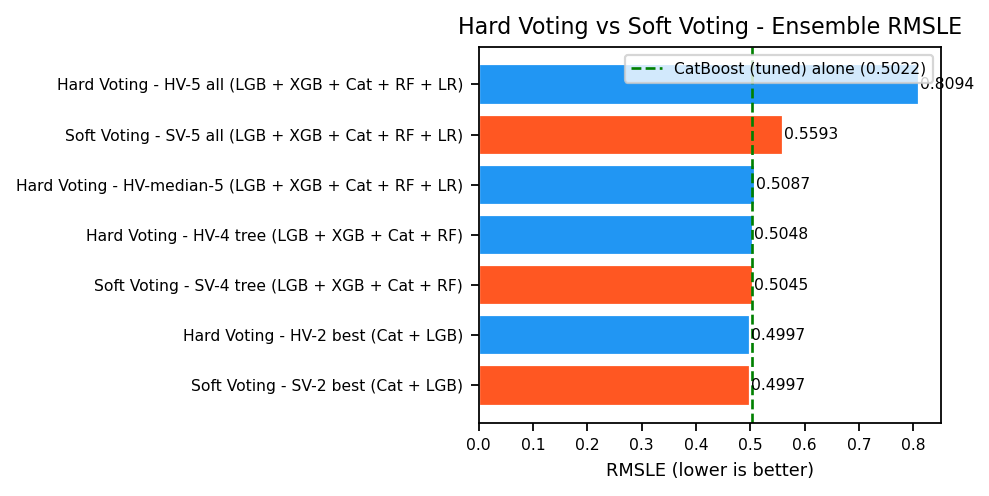

Saved to ..\docs\Report\Final Report\assets\ensemble_comparison.png


In [25]:
from pathlib import Path

FINAL_REPORT_ASSETS_DIR = Path("../docs/Report/Final Report/assets")
FINAL_REPORT_ASSETS_DIR.mkdir(parents=True, exist_ok=True)

if 'comparison' not in globals():
    comparison = pd.read_csv('../outputs/comparison_table.csv')

plot_df = comparison[comparison['Type'] == 'Ensemble'].copy()
single_rows = comparison[comparison['Type'] == 'Single'].copy()
best_single_idx = single_rows['Overall RMSLE'].idxmin()
single_best = single_rows.loc[best_single_idx, 'Overall RMSLE']
single_best_name = single_rows.loc[best_single_idx, 'Model']

fig_height = max(3.2, 0.30 * len(plot_df))
fig, ax = plt.subplots(figsize=(6.2, fig_height), dpi=160)
colors = ['#2196F3' if 'Hard Voting' in m else '#FF5722' for m in plot_df['Model']]
bars = ax.barh(plot_df['Model'], plot_df['Overall RMSLE'], color=colors, edgecolor='white')
ax.axvline(single_best, color='green', linestyle='--', linewidth=1.2, label=f'{single_best_name} alone ({single_best:.4f})')
ax.set_xlabel('RMSLE (lower is better)', fontsize=8)
ax.set_title('Hard Voting vs Soft Voting - Ensemble RMSLE', fontsize=10)
ax.tick_params(axis='both', labelsize=7)
ax.legend(fontsize=7)

for bar, v in zip(bars, plot_df['Overall RMSLE']):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=7)

fig.tight_layout()
fig.savefig(FINAL_REPORT_ASSETS_DIR / "ensemble_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to {FINAL_REPORT_ASSETS_DIR / 'ensemble_comparison.png'}")


---
## 4. Best Ensemble Predictions Saved

In [26]:
# Identify best ensemble strategy
ensemble_rmsles = {}
for name, result in hard_results.items():
    ensemble_rmsles[f'Hard Voting - {name}'] = (result['rmsle'], result['pred'])
for name, result in soft_results.items():
    ensemble_rmsles[f'Soft Voting - {name}'] = (result['rmsle'], result['pred'])

best_name = min(ensemble_rmsles, key=lambda k: ensemble_rmsles[k][0])
best_rmsle, best_pred = ensemble_rmsles[best_name]
best_single_spec = min(model_specs, key=lambda s: s['rmsle'])
best_single_name = best_single_spec['name']
best_single_rmsle = best_single_spec['rmsle']

print(f'Best ensemble: {best_name}  (RMSLE = {best_rmsle:.4f})')
print(f'Improvement over best single model ({best_single_name} {best_single_rmsle:.4f}): '
      f'{(best_single_rmsle - best_rmsle):.4f} ({(best_single_rmsle - best_rmsle)/best_single_rmsle*100:.2f}%)')

out = test[['building_id', 'meter', 'timestamp', 'meter_reading']].copy()
out['ensemble_pred'] = best_pred
out['strategy'] = best_name
out.to_csv('../outputs/ensemble_val_predictions.csv', index=False)
print(f'Saved ensemble_val_predictions.csv  ({len(out):,} rows)')

Best ensemble: Soft Voting - SV-2 best (Cat + LGB)  (RMSLE = 0.4997)
Improvement over best single model (CatBoost (tuned) 0.5022): 0.0025 (0.49%)
Saved ensemble_val_predictions.csv  (2,614,072 rows)


Soft Voting  key : SV-2 best (Cat + LGB)  | RMSLE = 0.499679
Hard Voting  key : HV-2 best (Cat + LGB)  | RMSLE = 0.499709


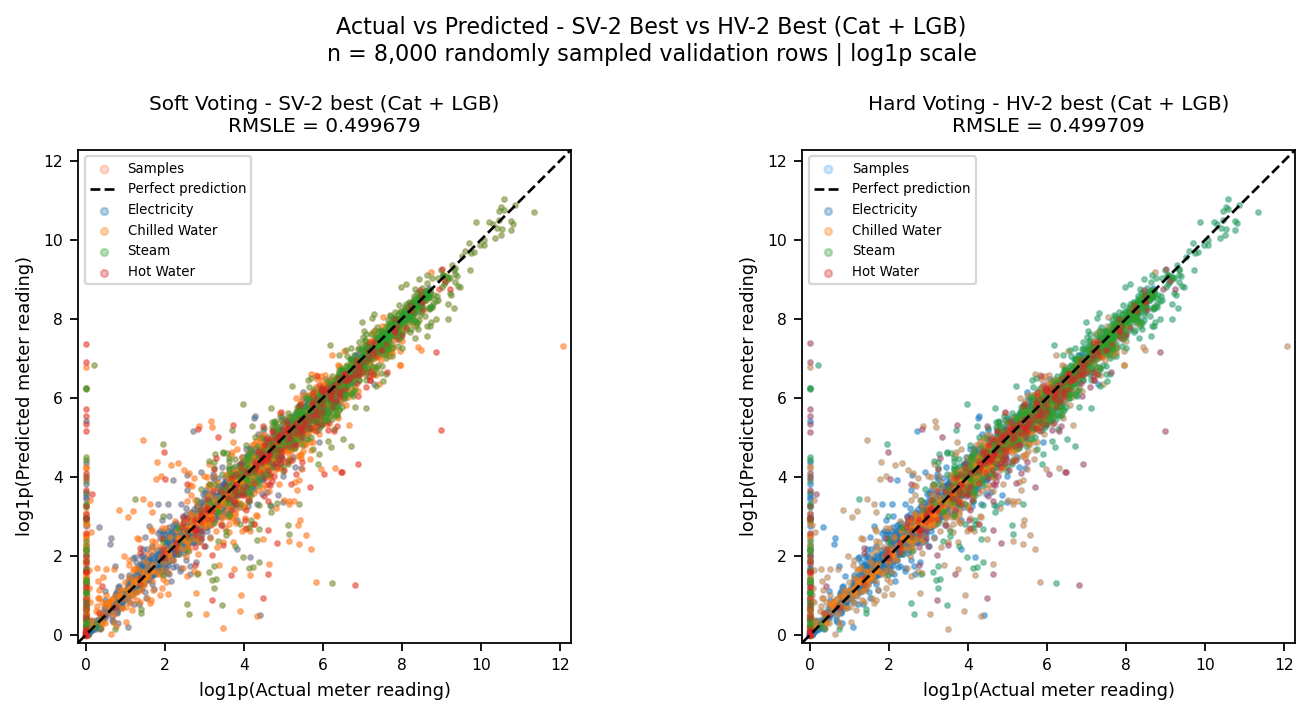

Plot saved to ..\docs\Report\Final Report\assets\actual_vs_predicted_sv2_hv2.png


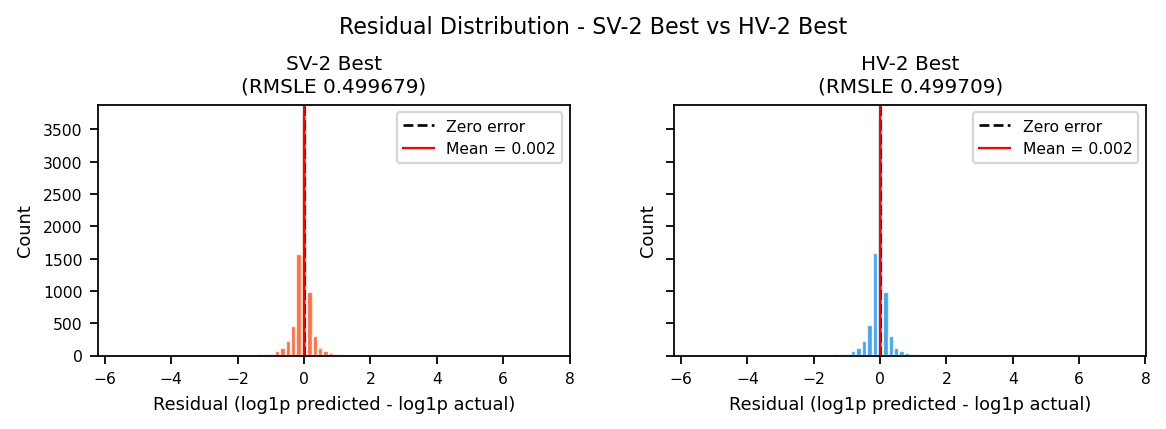

Residual plot saved to ..\docs\Report\Final Report\assets\residuals_sv2_hv2.png


In [27]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os
import pandas as pd
import joblib
from pathlib import Path

FINAL_REPORT_ASSETS_DIR = Path("../docs/Report/Final Report/assets")
FINAL_REPORT_ASSETS_DIR.mkdir(parents=True, exist_ok=True)

# 1. Locate the two target ensemble predictions.
def _existing_dir(*paths):
    for path in paths:
        if os.path.isdir(path):
            return path
    return paths[0]

OUTPUT_DIR = _existing_dir('../outputs', '!Project/outputs', 'outputs')
DATA_DIR = _existing_dir('../data_processed', '!Project/data_processed', 'data_processed')

def _lookup_saved_rmsle(model_prefix):
    comparison_path = os.path.join(OUTPUT_DIR, 'comparison_table.csv')
    if os.path.exists(comparison_path):
        comparison_saved = pd.read_csv(comparison_path)
        match = comparison_saved[comparison_saved['Model'].str.startswith(model_prefix, na=False)]
        if not match.empty:
            return float(match['Overall RMSLE'].iloc[0])
    return np.nan

def _model_feature_names(model):
    for attr in ('feature_names_in_', 'feature_names_', 'feature_name_'):
        if hasattr(model, attr):
            names = getattr(model, attr)
            if callable(names):
                names = names()
            if names is not None:
                names = list(names)
                if names:
                    return names
    return None

def _sample_X_for_model(df, model):
    drop_cols = ['meter_reading', 'log_meter_reading', 'timestamp']
    X = df.drop(columns=[col for col in drop_cols if col in df.columns])
    feature_names = _model_feature_names(model)
    if feature_names is not None:
        X = X.reindex(columns=feature_names, fill_value=0)
    return X.fillna(0)

class _LazyHV2Prediction:
    def __init__(self, features_path, output_dir, n_rows):
        self.features_path = features_path
        self.output_dir = output_dir
        self.n_rows = n_rows
        self.cache = {}
        self.lgb_model = None
        self.cat_model = None

    def __len__(self):
        return self.n_rows

    def _load_models(self):
        if self.lgb_model is None:
            self.lgb_model = globals().get('lgb_model')
            if self.lgb_model is None:
                self.lgb_model = joblib.load(os.path.join(self.output_dir, 'lightgbm_model.pkl'))
        if self.cat_model is None:
            self.cat_model = globals().get('cat_model')
            if self.cat_model is None:
                cat_path = os.path.join(self.output_dir, 'cat_tuned_model.pkl')
                if not os.path.exists(cat_path):
                    cat_path = os.path.join(self.output_dir, 'catboost_model.pkl')
                self.cat_model = joblib.load(cat_path)

    def _predict_missing(self, row_numbers):
        missing = np.array(sorted({int(row) for row in row_numbers if int(row) not in self.cache}))
        if missing.size == 0:
            return

        self._load_models()
        sample_lines = set((missing + 1).tolist())
        feature_sample = pd.read_csv(
            self.features_path,
            skiprows=lambda line_no: line_no != 0 and line_no not in sample_lines
        ).reset_index(drop=True)

        lgb_log = self.lgb_model.predict(_sample_X_for_model(feature_sample, self.lgb_model))
        cat_log = self.cat_model.predict(_sample_X_for_model(feature_sample, self.cat_model))
        lgb_pred = np.expm1(np.maximum(lgb_log, 0))
        cat_pred = np.expm1(np.maximum(cat_log, 0))
        hv2_pred = np.mean(np.stack([cat_pred, lgb_pred], axis=1), axis=1)

        for row_number, pred in zip(missing, hv2_pred):
            self.cache[int(row_number)] = float(pred)

    def __getitem__(self, rows):
        if isinstance(rows, slice):
            row_array = np.arange(self.n_rows)[rows]
        else:
            row_array = np.asarray(rows)
        flat_rows = row_array.reshape(-1)
        self._predict_missing(flat_rows)
        values = np.array([self.cache[int(row)] for row in flat_rows])
        return values.reshape(row_array.shape)

if not all(name in globals() for name in ['soft_results', 'hard_results', 'y_val', 'test']):
    print('soft_results/hard_results are not in memory; loading saved outputs for this final cell only.')
    saved_predictions_path = os.path.join(OUTPUT_DIR, 'ensemble_val_predictions.csv')
    features_path = os.path.join(DATA_DIR, 'final_test_with_features.csv')
    if not os.path.exists(saved_predictions_path):
        raise FileNotFoundError(f'Missing saved predictions: {saved_predictions_path}')
    if not os.path.exists(features_path):
        raise FileNotFoundError(f'Missing validation features: {features_path}')

    saved_predictions = pd.read_csv(
        saved_predictions_path,
        usecols=['meter', 'meter_reading', 'ensemble_pred']
    )
    y_val = saved_predictions['meter_reading'].to_numpy()
    test = saved_predictions[['meter']].copy()
    soft_results = {
        'SV-2 best (Cat + LGB)': {
            'pred': saved_predictions['ensemble_pred'].to_numpy(),
            'rmsle': _lookup_saved_rmsle('Soft Voting - SV-2 best')
        }
    }
    hard_results = {
        'HV-2 best (Cat + LGB)': {
            'pred': _LazyHV2Prediction(features_path, OUTPUT_DIR, len(y_val)),
            'rmsle': _lookup_saved_rmsle('Hard Voting - HV-2 best')
        }
    }

if 'METER_NAMES' not in globals():
    METER_NAMES = {0: 'Electricity', 1: 'Chilled Water', 2: 'Steam', 3: 'Hot Water'}

sv2_key = next(k for k in soft_results if k.startswith("SV-2 best"))
hv2_key = next(k for k in hard_results if k.startswith("HV-2 best"))

sv2_pred  = soft_results[sv2_key]["pred"]
hv2_pred  = hard_results[hv2_key]["pred"]
sv2_rmsle = soft_results[sv2_key]["rmsle"]
hv2_rmsle = hard_results[hv2_key]["rmsle"]

print(f"Soft Voting  key : {sv2_key}  | RMSLE = {sv2_rmsle:.6f}")
print(f"Hard Voting  key : {hv2_key}  | RMSLE = {hv2_rmsle:.6f}")

# 2. Sample for scatter.
np.random.seed(42)
n_sample = 8000
idx = np.random.choice(len(y_val), size=n_sample, replace=False)

y_actual = y_val[idx]
y_sv2    = sv2_pred[idx]
y_hv2    = hv2_pred[idx]

# Work in log1p space so the dense low-value region does not dominate.
log_actual = np.log1p(y_actual)
log_sv2    = np.log1p(y_sv2)
log_hv2    = np.log1p(y_hv2)

# 3. Actual vs predicted plot.
fig = plt.figure(figsize=(8.8, 4.4), dpi=160)
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.30)

plot_configs = [
    (gs[0], log_sv2,  f"Soft Voting - {sv2_key}\nRMSLE = {sv2_rmsle:.6f}", "#FF5722"),
    (gs[1], log_hv2,  f"Hard Voting - {hv2_key}\nRMSLE = {hv2_rmsle:.6f}", "#2196F3"),
]

for spec, (gs_pos, log_pred, title, colour) in enumerate(plot_configs):
    ax = fig.add_subplot(gs_pos)
    ax.scatter(log_actual, log_pred, alpha=0.22, s=5, color=colour, label="Samples")

    lim_min = min(log_actual.min(), log_pred.min()) - 0.2
    lim_max = max(log_actual.max(), log_pred.max()) + 0.2
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            color="black", linewidth=1.2, linestyle="--", label="Perfect prediction")

    for m, mname in METER_NAMES.items():
        mask = test["meter"].values[idx] == m
        ax.scatter(log_actual[mask], log_pred[mask],
                   alpha=0.32, s=4, label=mname)

    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    ax.set_xlabel("log1p(Actual meter reading)", fontsize=8)
    ax.set_ylabel("log1p(Predicted meter reading)", fontsize=8)
    ax.set_title(title, fontsize=9, pad=8)
    ax.legend(fontsize=6, markerscale=1.6)
    ax.tick_params(axis='both', labelsize=7)
    ax.set_aspect("equal", adjustable="box")

fig.suptitle(
    "Actual vs Predicted - SV-2 Best vs HV-2 Best (Cat + LGB)\n"
    f"n = {n_sample:,} randomly sampled validation rows | log1p scale",
    fontsize=10, y=1.01
)

fig.subplots_adjust(top=0.82, bottom=0.12, left=0.07, right=0.98, wspace=0.28)
actual_plot_path = FINAL_REPORT_ASSETS_DIR / 'actual_vs_predicted_sv2_hv2.png'
plt.savefig(actual_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Plot saved to {actual_plot_path}')

# 4. Residual distribution.
fig2, axes = plt.subplots(1, 2, figsize=(7.2, 2.8), dpi=160, sharey=True)

for ax, (log_pred, label, colour) in zip(
    axes,
    [(log_sv2, f"SV-2 Best\n(RMSLE {sv2_rmsle:.6f})", "#FF5722"),
     (log_hv2, f"HV-2 Best\n(RMSLE {hv2_rmsle:.6f})", "#2196F3")]
):
    residuals = log_pred - log_actual
    ax.hist(residuals, bins=80, color=colour, edgecolor="white", alpha=0.85)
    ax.axvline(0, color="black", linewidth=1.2, linestyle="--", label="Zero error")
    ax.axvline(residuals.mean(), color="red", linewidth=1.0, linestyle="-",
               label=f"Mean = {residuals.mean():.3f}")
    ax.set_xlabel("Residual (log1p predicted - log1p actual)", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ax.set_title(label, fontsize=9)
    ax.tick_params(axis='both', labelsize=7)
    ax.legend(fontsize=7)

fig2.suptitle("Residual Distribution - SV-2 Best vs HV-2 Best", fontsize=10)
fig2.subplots_adjust(top=0.78, bottom=0.22, left=0.07, right=0.98, wspace=0.22)
residual_plot_path = FINAL_REPORT_ASSETS_DIR / 'residuals_sv2_hv2.png'
plt.savefig(residual_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Residual plot saved to {residual_plot_path}')


---
## Summary

### Hard Voting vs Soft Voting — Key Takeaways

| | Hard Voting | Soft Voting |
|---|---|---|
| **Weights** | Equal (1/N) | Performance-based (1/RMSLE²) |
| **Effect of weak model** | Drags ensemble toward weak model | Weak model auto-down-weighted |
| **Best when** | All models perform similarly | Models have different quality levels |
| **Our case** | HV-4-tree / HV-5-all show the equal-vote effect across all project models | SV-5-all includes every model while down-weighting weak models automatically |

The notebook includes all five project models: LightGBM, XGBoost, CatBoost, Random Forest, and Linear Regression. XGBoost and CatBoost are evaluated as individual models and are included in the hard-voting, soft-voting, per-meter, comparison, plot, and saved best-ensemble sections.